# RSML architecture

Read architecture from RSML file and run a simulation to illustrate how to use the RSML format (http://rootsystemml.github.io/). The architecture is the arabidopsis-simple example from http://rootsystemml.github.io/images/examples/arabidopsis-simple.rsml.

Point to the source files if the notebook is run locally, from a git repository clone for example, without openalea.hydroroot installation, but only the dependencies installed.

In [20]:
from openalea.plantgl.algo.view import view # 2D view
from openalea.widgets.plantgl import PlantGL # 3D viewer

# Import HydroRoot modules
from openalea import hydroroot
from openalea.hydroroot import (
    main,
    hydro_io,
    radius,
    display,
)

## RSML to MTG

 Read the rsml file *arabidopsis.rsml* and convert it to a MTG *g* of segments of 0.1 mm

In [12]:
g = hydroroot.hydro_io.read_rsml('data/arabidopsis-simple.rsml', segment_length=1.0e-4)

## Run calculation

### Set the root radii
   The radius setting follows the Arabidopsis model describeded in Boursiac et al. 2022. The root radius is set according to the radius of the primary root $r_{ref}$ and the order of the lateral as follows: $r_{lat} = \beta^{order} r_{ref}$. $\beta$ is the radius decreasing facteur between root orders.

In [13]:
# primary root radius 7.0e-5 m, beta = 0.7
g = hydroroot.radius.ordered_radius(g,
                                    ref_radius=7.0e-5,
                                    order_decrease_factor=0.7)

# Compute the position of each segment relative to the axis bearing it
g = hydroroot.radius.compute_relative_position(g)

### Set hydraulic properties

In [14]:
# radial conductivity profile: distance to tip (m) vs kr (10-9 m.s-1.MPa-1)
k_radial_data=([0, 0.2],[30.0,30.0])

# axial conductance profile: distance to tip (m) vs Kx (10-9 m4.s-1.MPa-1)
K_axial_data=([0, 0.2],[3.0e-7,4.0e-4])

### Flux and equivalent conductance calculation
Eor a root in an external hydroponic medium at 0.4 MPa, its base at 0.1 MPa, and with the conductances set above.

In [15]:
g, keq, jv = hydroroot.main.hydroroot_flow(g, psi_e = 0.4, psi_base = 0.1, axial_conductivity_data = K_axial_data, radial_conductivity_data = k_radial_data)

Print results

In [17]:
print(f'equivalent root conductance (10-9 m3/s/MPa): {keq} sap flux (microL/s): {jv}')

equivalent root conductance (10-9 m3/s/MPa): 0.0014303117762878164 sap flux (microL/s): 0.000429093532886345


## Display the local water uptake heatmap

to reduce notebook size we use here a 2D view but you can use the openalea.widgets `PlantGL(s)` to display an interactive 3D view

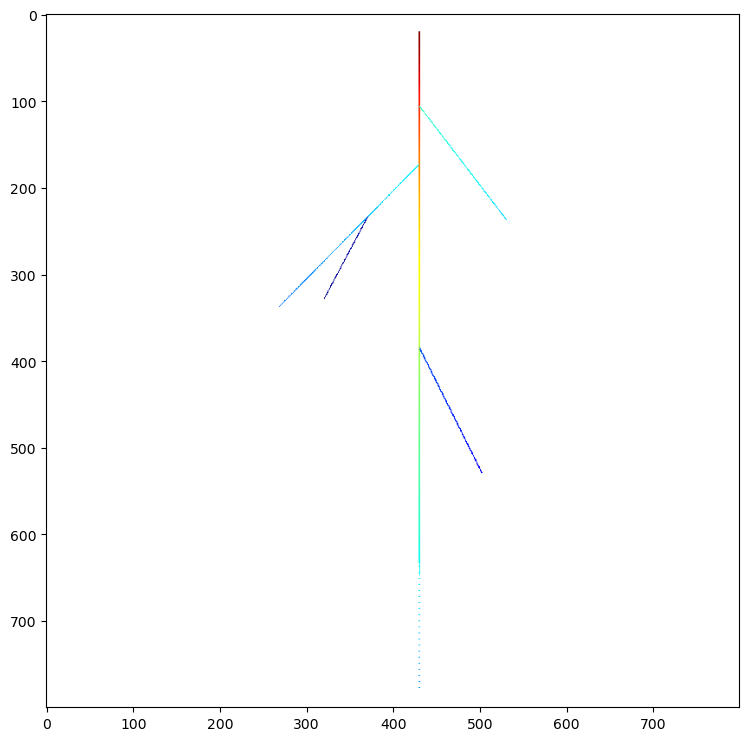

In [18]:
# create a scene from the mtg with the property j is the radial flux in ul/s
s = hydroroot.display.mtg_scene(g, prop_cmap = 'j')

view(s) # use PlantGL(s) to display in 3D

## Export the MTG to RSML

At this stage (2022-08-22) only the root length and the branching position are used to simulate architecture in hydroponic solution. The exact position in 3D is not stored in the discrete MTG form and so not exported to RMSL.

In [19]:
hydroroot.hydro_io.export_mtg_to_rsml(g, "test.rsml", segment_length = 1.0e-4)

The resolution of the RSML data is 1.0e-4 and the unit is meter.